In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import torch
import numpy as np
import pandas as pd

from flonacomldft.utils.io_utils import (load_pickle_file,
    get_project_path,
    load_csv_file
)

from flonacomldft.models.mlp import MLP
from flonacomldft.train_mlp_from_data import train_mlp

import matplotlib.pyplot as plt

from sklearn.feature_selection import mutual_info_regression

In [3]:
path_from_adaptive = "/1-adaptive"
adaptive_to_load = lambda isomer, idx: "results_adaptive_is{:d}_{:d}/adaptive_sampling_is{:d}_{:d}.pkl".format(
        isomer, 
        idx, 
        isomer, 
        idx)

In [4]:
mcmcs = {i: torch.cat(load_pickle_file(adaptive_to_load(i, idx),
        get_project_path() + path_from_adaptive)['xs']) for i, idx in enumerate([31961552, 31961553])}

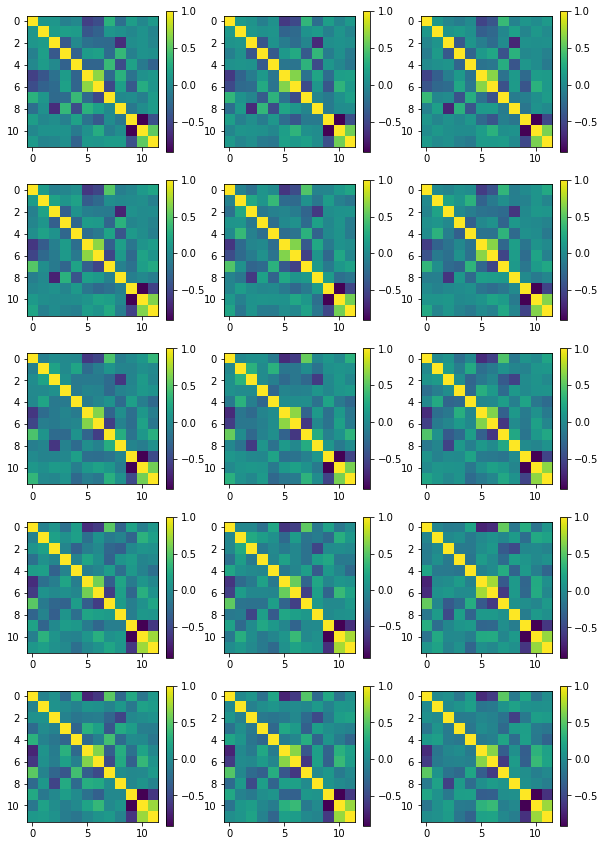

In [38]:
fig, axs = plt.subplots(5, 3, figsize=(10, 15))
axs = axs.ravel()
for i, ax in enumerate(axs):
    im = ax.imshow(torch.corrcoef(mcmcs[0][i, :].transpose(0, 1)))
    # add colorbar
    cbar = ax.figure.colorbar(im, ax=ax)

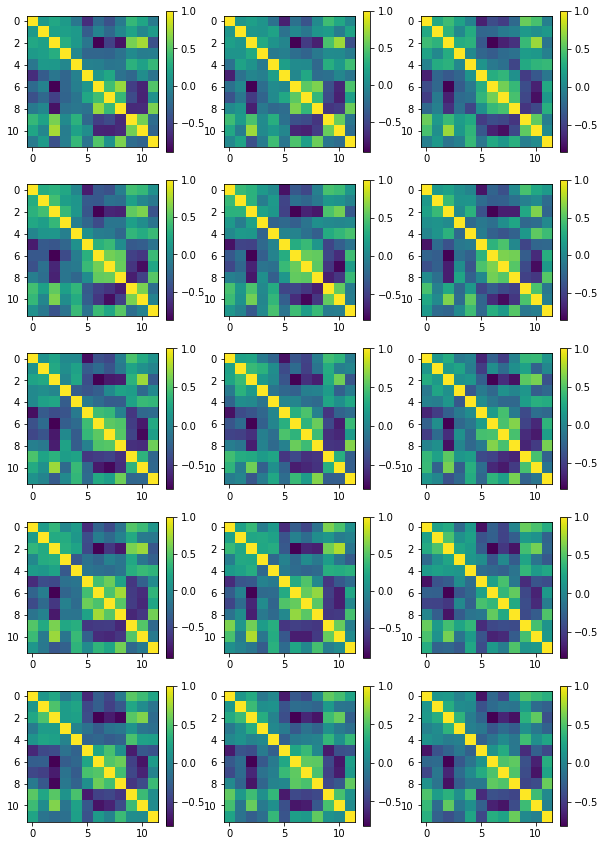

In [39]:
fig, axs = plt.subplots(5, 3, figsize=(10, 15))
axs = axs.ravel()
for i, ax in enumerate(axs):
    im = ax.imshow(torch.corrcoef(mcmcs[1][i, :].transpose(0, 1)))
    # add colorbar
    cbar = ax.figure.colorbar(im, ax=ax)

In [25]:
#run correlation using steps of the MD and the random data

In [26]:
mcmcs[0].shape

torch.Size([1000, 50, 12])

In [40]:
mutual_info_matrix = []

for i in range(12):
    print(mutual_info_regression(mcmcs[0][::10, 0].detach().numpy(), mcmcs[0][::10, 0].detach().numpy()[:, i]))
    mutual_info_matrix.append(
        mutual_info_regression(mcmcs[0][::10, 0].detach().numpy(), mcmcs[0][::10, 0].detach().numpy()[:, i])
    )

[3.34904418 0.02793585 0.         0.03256608 0.05573173 0.26397436
 0.18211988 0.07848667 0.         0.         0.         0.        ]
[0.02694285 3.34154418 0.11061842 0.         0.01027504 0.21578633
 0.05539413 0.02496173 0.1020817  0.06276645 0.03176986 0.00984696]
[0.         0.11728508 3.33654418 0.         0.10001888 0.
 0.         0.         0.14285686 0.03896213 0.01460904 0.06196483]
[0.03389183 0.         0.         3.34404418 0.06129989 0.
 0.04442427 0.06379378 0.210013   0.04799636 0.         0.        ]
[0.05673173 0.01027504 0.10143555 0.0648908  3.35654418 0.07855847
 0.         0.03202309 0.29752065 0.         0.         0.01752399]
[0.2611218  0.22023414 0.         0.         0.08346756 3.33904418
 0.26392288 0.07089071 0.         0.01118185 0.         0.        ]
[0.17903958 0.05456079 0.         0.04476517 0.         0.26594308
 3.34154418 0.06715781 0.01327404 0.18077498 0.0618174  0.14435065]


[0.07848667 0.02350339 0.         0.06293963 0.03514698 0.0717998
 0.06799114 3.35154418 0.14314243 0.         0.19220903 0.        ]
[0.         0.1042795  0.14428543 0.206842   0.30142065 0.
 0.01229327 0.14338633 3.33654418 0.         0.01456625 0.11026369]
[0.         0.0622109  0.03948845 0.04899636 0.         0.00998741
 0.1819476  0.         0.         3.34654418 1.02315807 0.59641335]
[0.         0.02888097 0.02460904 0.         0.         0.
 0.06001184 0.1908454  0.01285811 1.02315807 3.32904418 0.64045839]
[0.         0.0100109  0.06370094 0.         0.0220543  0.
 0.14484307 0.         0.11026218 0.59641335 0.64223617 3.34654418]


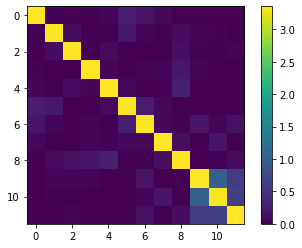

In [41]:
plt.imshow(mutual_info_matrix)
plt.colorbar()

In [ ]:
mutual_info_matrix = []

for i in range(12):
    print(mutual_info_regression(mcmcs[0][::10, 0].detach().numpy(), mcmcs[0][::10, 0].detach().numpy()[:, i]))
    mutual_info_matrix.append(
        mutual_info_regression(mcmcs[0][::10, 0].detach().numpy(), mcmcs[0][::10, 0].detach().numpy()[:, i])
    )